# Raw Image Display (No Preprocessing)

This notebook displays the same images analyzed in SAM_Visualization_Fixed.ipynb
but WITHOUT any preprocessing:
- ❌ No ToCanonical
- ❌ No ResizeLargestTo
- ❌ No CropOrPad
- ❌ No ZNormalization

Just the raw NIFTI volumes as they are!

In [1]:
import sys
from pathlib import Path
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import yaml
import random

In [2]:
# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"✅ Project root: {project_root}")

✅ Project root: c:\Users\cahel\Desktop\Med3Tab-PFN


## Configuration

In [3]:
# Load datasets config
config_path = project_root / "configs" / "datasets.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Find SAM-Med3D data directory
sam3d_root = project_root / "SAM-Med3D-main" / "SAM-Med3D-main"
if not sam3d_root.exists():
    sam3d_root = project_root / "SAM-Med3D-main"

print(f"SAM-Med3D root: {sam3d_root}")
print(f"Available datasets: {list(config['datasets'].keys())}")

SAM-Med3D root: c:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main
Available datasets: ['gist', 'lipo']


In [4]:
# Settings
n_samples_per_dataset = 2
n_slices = 5  # Number of slices to display
random.seed(42)
np.random.seed(42)

## Helper Functions

In [5]:
def find_dataset_images(dataset_config, sam3d_root, project_root):
    """Find all images and labels for a dataset."""
    images, labels = [], []
    category = dataset_config['category']
    ct_name = dataset_config['ct_name']
    
    possible_paths = [
        sam3d_root / 'data' / 'train' / category / ct_name / 'imagesTr',
        sam3d_root / 'data' / 'validation' / category / ct_name / 'imagesVal',
    ]
    
    for path in possible_paths:
        if path.exists():
            imgs = list(path.glob('*.nii.gz'))
            images.extend(imgs)
            label_path = path.parent / path.name.replace('images', 'labels')
            if label_path.exists():
                for img in imgs:
                    label_file = label_path / img.name
                    if label_file.exists():
                        labels.append(label_file)
    return images, labels

In [6]:
def load_raw_volume(img_path):
    """
    Load COMPLETELY RAW volume - NO PREPROCESSING AT ALL!
    
    Just reads the NIFTI file and returns the numpy array.
    """
    sitk_img = sitk.ReadImage(str(img_path))
    volume = sitk.GetArrayFromImage(sitk_img)
    
    # Apply CT clamping ONLY for better visualization (optional)
    if "/ct_" in str(img_path).lower() or "_ct" in str(img_path).lower():
        volume = np.clip(volume, -1000, 1000)
    
    return volume

In [7]:
def load_raw_mask(mask_path):
    """Load raw mask without preprocessing."""
    sitk_mask = sitk.ReadImage(str(mask_path))
    mask = sitk.GetArrayFromImage(sitk_mask)
    mask = (mask > 0).astype(float)
    return mask

## Visualization Function

In [8]:
def plot_raw_coronal_slices(image_vol, gt_mask_vol=None, title="", n_slices=5, modality="CT"):
    """
    Plot RAW coronal slices without any preprocessing.
    
    Note: The original shape and dimensions are preserved.
    """
    print(f"    Raw volume shape: {image_vol.shape}")
    print(f"    Intensity range: [{image_vol.min():.2f}, {image_vol.max():.2f}]")
    
    # For medical images, the axis order is typically (Z, Y, X) after GetArrayFromImage
    # Coronal view means looking from front to back, so we slice along Y axis
    Z, Y, X = image_vol.shape
    
    # Select slices from Y dimension (coronal)
    # Find slices with content
    slice_sums = np.abs(image_vol).sum(axis=(0, 2))  # Sum over Z and X for each Y
    threshold = slice_sums.max() * 0.05
    content_slices = np.where(slice_sums > threshold)[0]
    
    if len(content_slices) == 0:
        content_slices = np.arange(Y//4, 3*Y//4)
    
    # Select evenly spaced slices
    if len(content_slices) >= n_slices:
        indices = np.linspace(0, len(content_slices)-1, n_slices, dtype=int)
        slice_indices = content_slices[indices]
    else:
        slice_indices = content_slices
        n_slices = len(slice_indices)
    
    print(f"    Selected coronal slices (Y-axis): {slice_indices}")
    
    # Calculate display window
    foreground_mask = image_vol > (image_vol.min() + 0.05 * (image_vol.max() - image_vol.min()))
    if foreground_mask.sum() > 100:
        foreground_vals = image_vol[foreground_mask]
        if "MR" in modality.upper():
            vmin, vmax = np.percentile(foreground_vals, [1, 99])
        else:
            mean_val = foreground_vals.mean()
            std_val = foreground_vals.std()
            vmin = mean_val - 2 * std_val
            vmax = mean_val + 2 * std_val
            vmin = max(vmin, foreground_vals.min())
            vmax = min(vmax, foreground_vals.max())
    else:
        vmin, vmax = image_vol.min(), image_vol.max()
    
    print(f"    Display window: [{vmin:.2f}, {vmax:.2f}]")
    
    # Create plot
    n_cols = 2 if gt_mask_vol is not None else 1
    fig, axes = plt.subplots(n_slices, n_cols, figsize=(6*n_cols, 4*n_slices))
    
    if n_slices == 1:
        axes = axes.reshape(1, -1) if n_cols > 1 else np.array([[axes]])
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, slice_idx in enumerate(slice_indices):
        # Extract coronal slice (from Y dimension)
        coronal_slice = image_vol[:, slice_idx, :]
        
        # Original image
        axes[i, 0].imshow(coronal_slice, cmap='gray', vmin=vmin, vmax=vmax)
        axes[i, 0].set_title(f"Raw Volume (coronal Y={slice_idx})")
        axes[i, 0].axis('off')
        
        # Ground truth overlay (if available)
        if gt_mask_vol is not None:
            gt_slice = gt_mask_vol[:, slice_idx, :]
            axes[i, 1].imshow(coronal_slice, cmap='gray', vmin=vmin, vmax=vmax)
            gt_overlay = np.ma.masked_where(gt_slice == 0, gt_slice)
            axes[i, 1].imshow(gt_overlay, cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            axes[i, 1].set_title(f"With Ground Truth (coronal Y={slice_idx})")
            axes[i, 1].axis('off')
    
    fig.suptitle(f"{title}\n[RAW - No Preprocessing | {modality} | Shape: {image_vol.shape}]", 
                 fontsize=14, y=0.995)
    plt.tight_layout()
    return fig

## Process and Display Images


Processing dataset: GIST
Found 296 images

📁 Processing: GIST-058_CT.nii.gz
  Loading RAW volume (no preprocessing)...
  Loading RAW mask...
    Mask voxels: 133450
  Plotting RAW coronal slices [Modality: CT]...
    Raw volume shape: (209, 512, 512)
    Intensity range: [-1000.00, 1000.00]
    Selected coronal slices (Y-axis): [  0 127 255 383 511]
    Display window: [-808.84, 519.91]


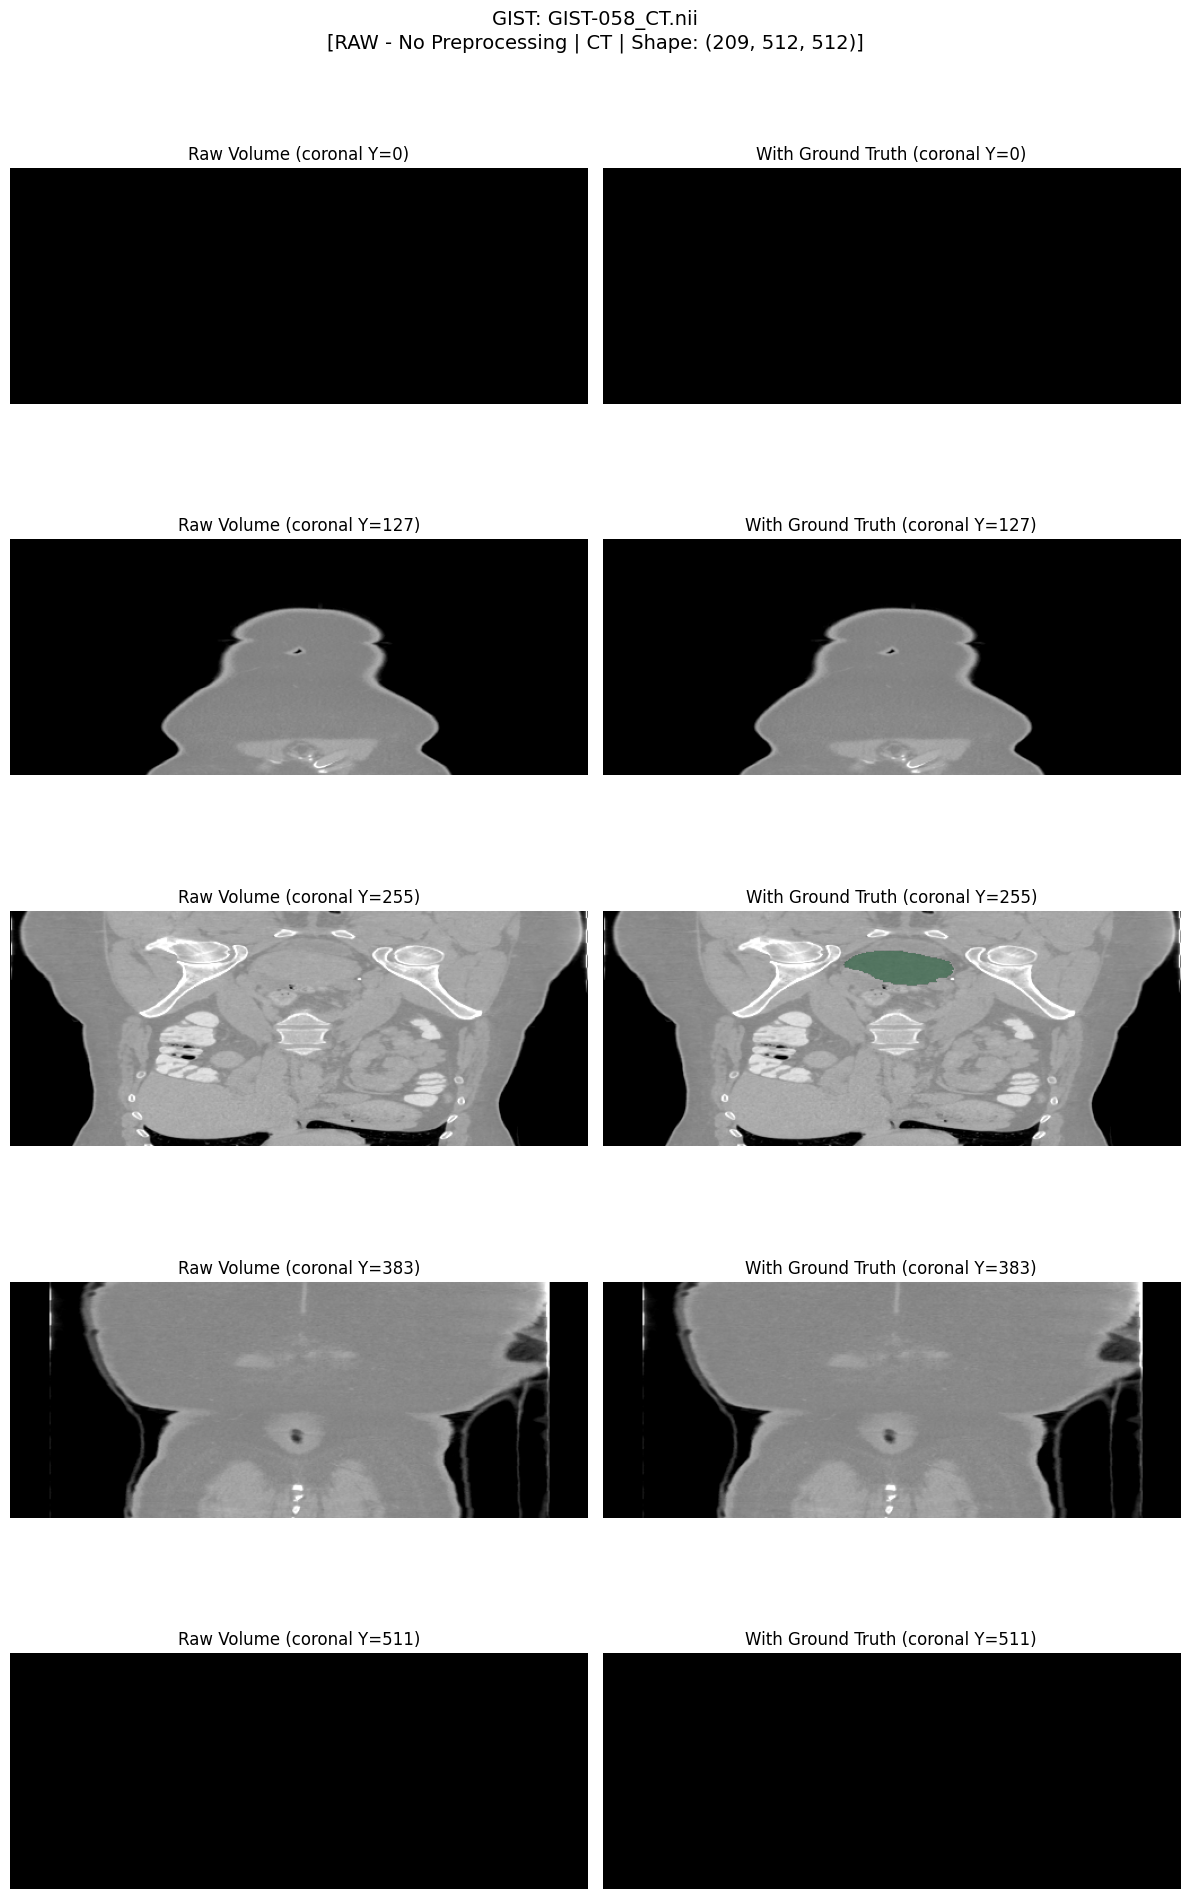


📁 Processing: GIST-013_CT.nii.gz
  Loading RAW volume (no preprocessing)...
  Loading RAW mask...
    Mask voxels: 34591
  Plotting RAW coronal slices [Modality: CT]...
    Raw volume shape: (76, 512, 512)
    Intensity range: [-1000.00, 1000.00]
    Selected coronal slices (Y-axis): [  0 127 255 383 511]
    Display window: [-565.38, 433.94]


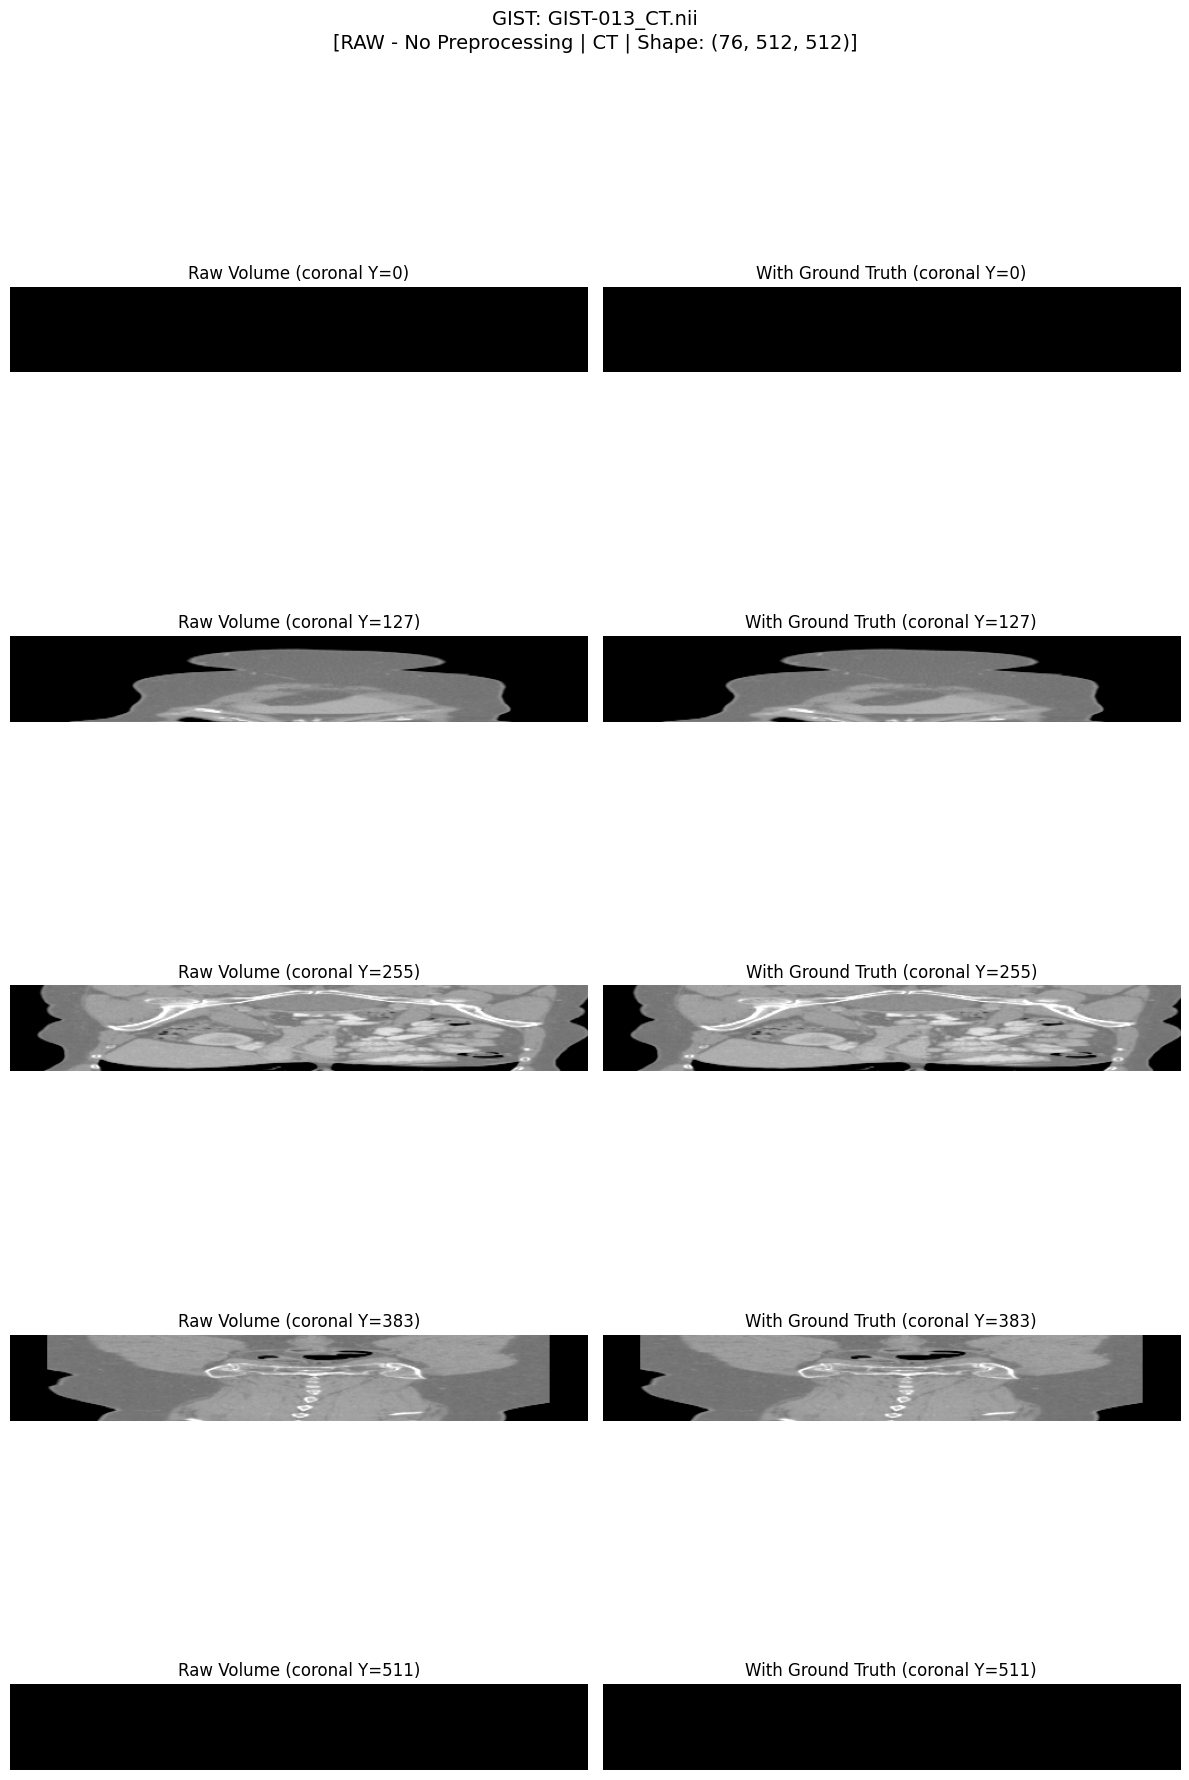


Processing dataset: LIPO
Found 138 images

📁 Processing: Lipo-071_MR.nii.gz
  Loading RAW volume (no preprocessing)...
  Loading RAW mask...
    Mask voxels: 58060
  Plotting RAW coronal slices [Modality: MR]...
    Raw volume shape: (25, 512, 512)
    Intensity range: [0.00, 3402.30]
    Selected coronal slices (Y-axis): [  0  82 164 246 329]
    Display window: [175.80, 2777.93]


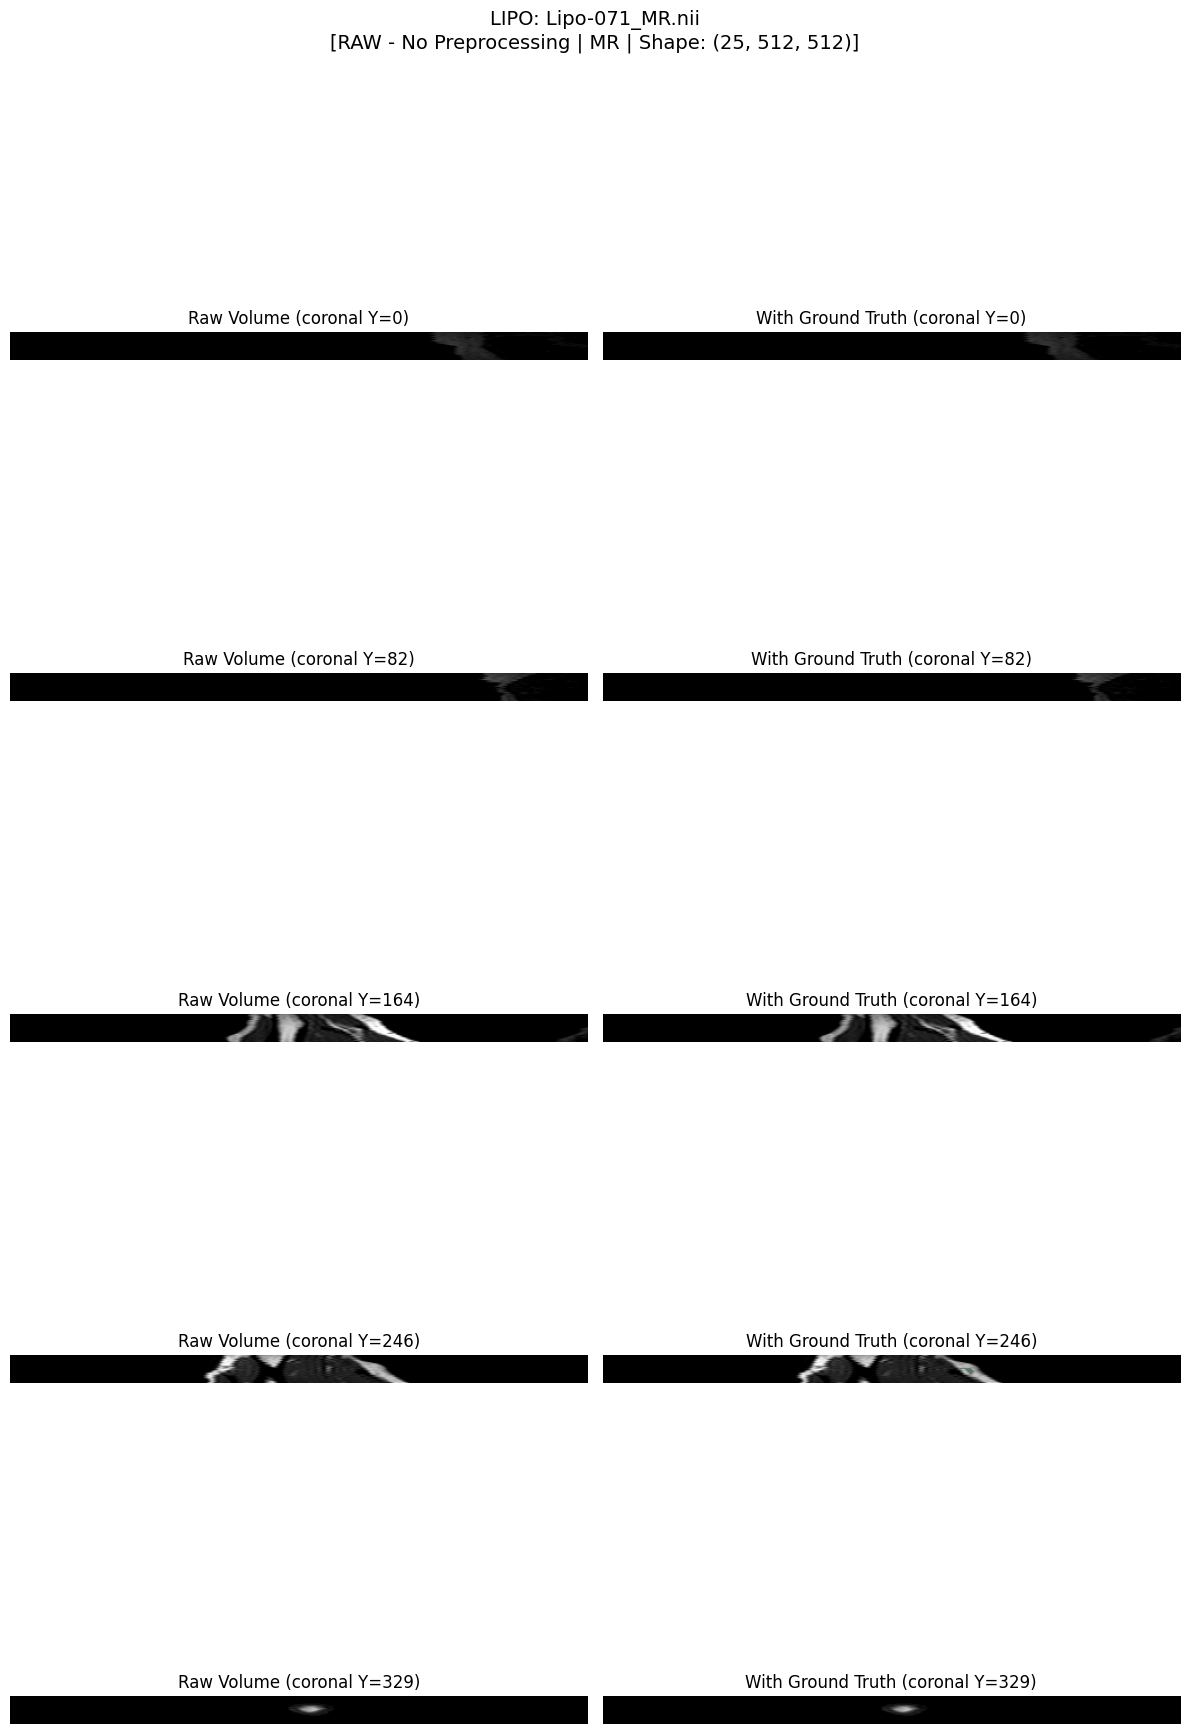


📁 Processing: Lipo-063_MR.nii.gz
  Loading RAW volume (no preprocessing)...
  Loading RAW mask...
    Mask voxels: 32255
  Plotting RAW coronal slices [Modality: MR]...
    Raw volume shape: (36, 640, 640)
    Intensity range: [0.00, 2519.64]
    Selected coronal slices (Y-axis): [104 185 267 349 431]
    Display window: [213.11, 2102.82]


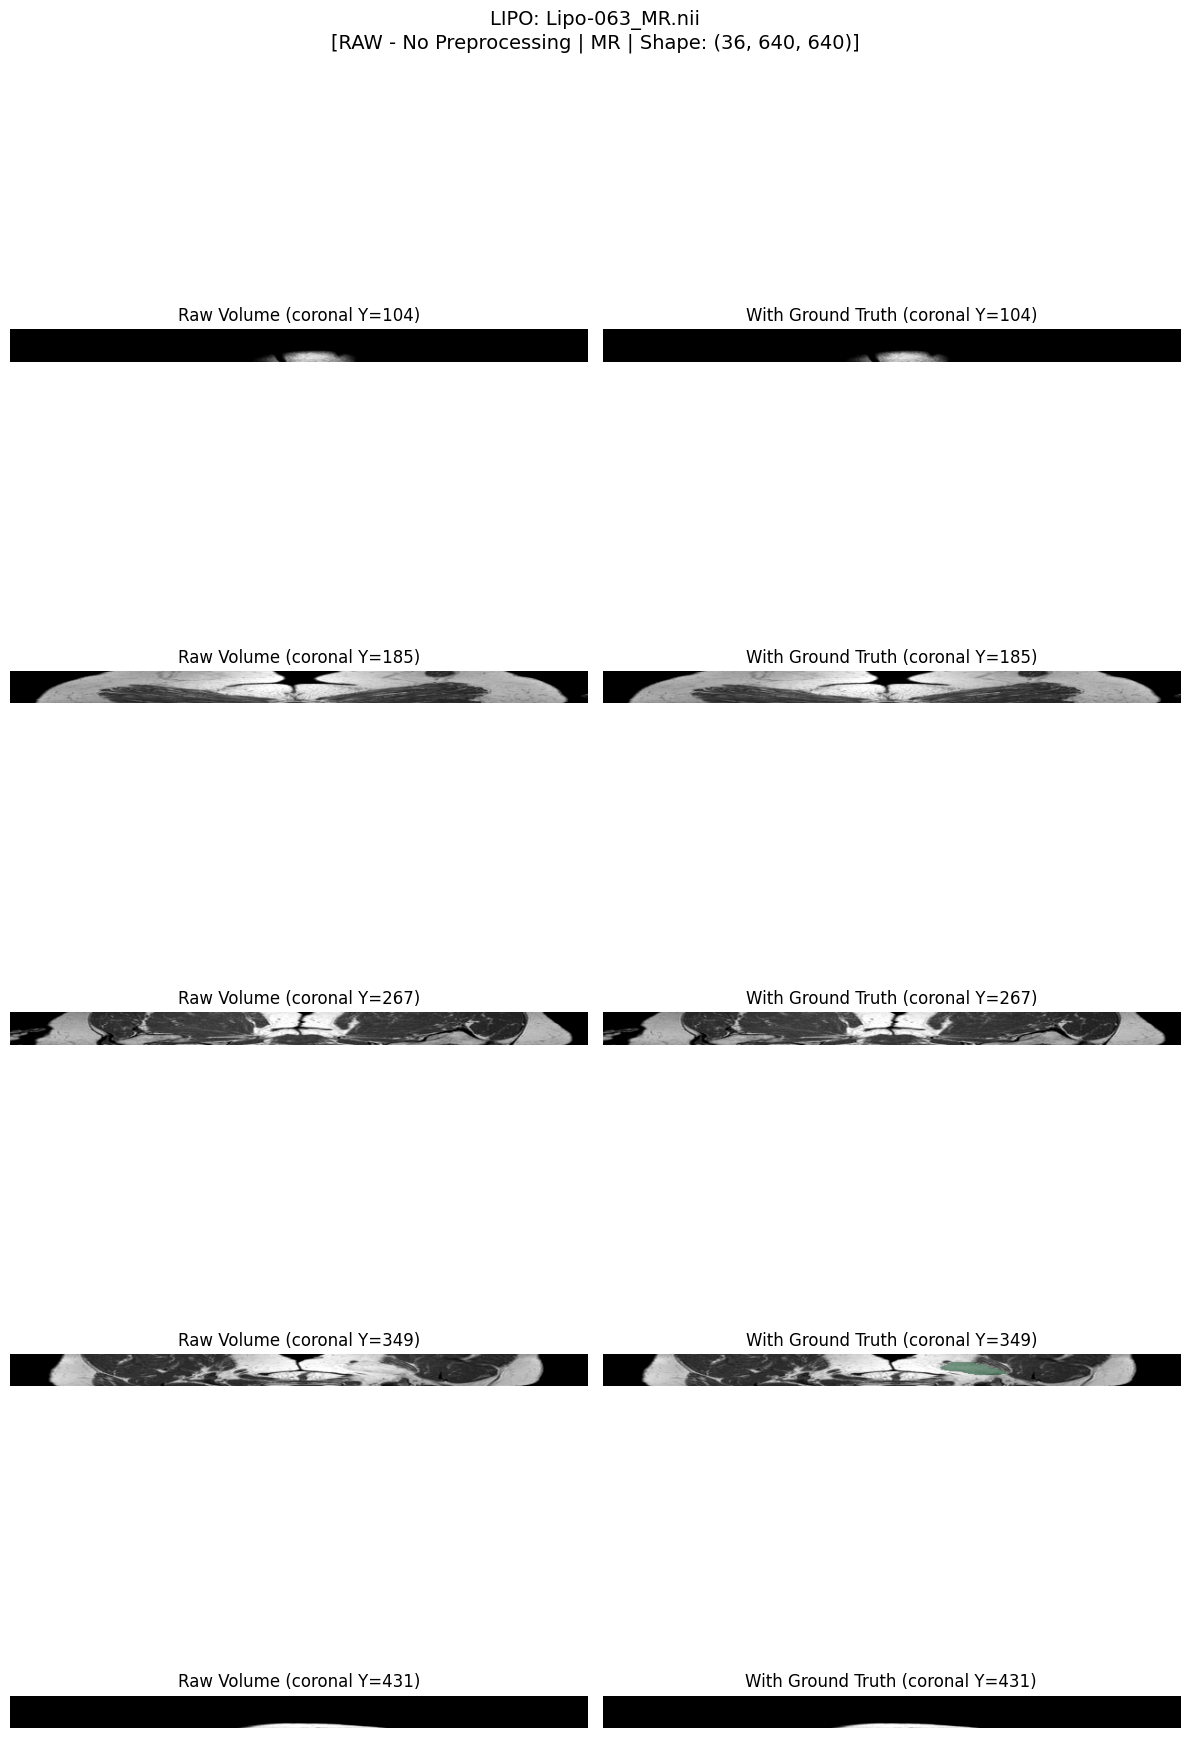

In [9]:
for dataset_name, dataset_config in config['datasets'].items():
    print("\n" + "="*60)
    print(f"Processing dataset: {dataset_name.upper()}")
    print("="*60)
    
    images, labels = find_dataset_images(dataset_config, sam3d_root, project_root)
    print(f"Found {len(images)} images")
    
    if len(images) == 0:
        print(f"  ⚠️ No images found for {dataset_name}")
        continue
    
    
    # Use same random samples as in SAM_Visualization_Fixed
    sample_indices = random.sample(range(len(images)), min(n_samples_per_dataset, len(images)))
    
    for idx in sample_indices:
        img_path = images[idx]
        label_path = labels[idx] if idx < len(labels) else None
        
        print(f"\n📁 Processing: {img_path.name}")
        
        try:
            # Load RAW volume (NO preprocessing!)
            print("  Loading RAW volume (no preprocessing)...")
            raw_volume = load_raw_volume(img_path)
            
            # Load RAW mask if available
            raw_mask = None
            if label_path and label_path.exists():
                print("  Loading RAW mask...")
                raw_mask = load_raw_mask(label_path)
                print(f"    Mask voxels: {raw_mask.sum():.0f}")
            
            # Detect modality
            modality = "MR" if "_MR" in img_path.name or "Lipo" in img_path.name else "CT"
            
            # Plot
            print(f"  Plotting RAW coronal slices [Modality: {modality}]...")
            fig = plot_raw_coronal_slices(
                raw_volume,
                raw_mask,
                title=f"{dataset_name.upper()}: {img_path.stem}",
                n_slices=n_slices,
                modality=modality
            )
            plt.show()
            
        except Exception as e:
            print(f"  ❌ Error processing {img_path.name}: {e}")
            import traceback
            traceback.print_exc()

## Summary

✅ **All images displayed WITHOUT any preprocessing:**
- Original resolution preserved
- Original orientation preserved  
- No normalization
- No resizing or padding

Compare these with SAM_Visualization_Fixed.ipynb to see the effect of preprocessing!